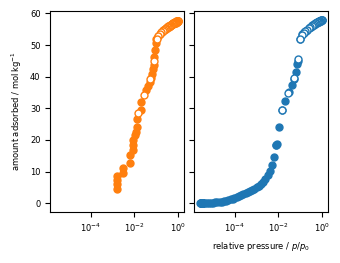

<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
from gemmi import cif
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 6})

# Plotting multiple isotherms from AIF and digitized data
# read the AIF data
aif_data = cif.read_file("isotherm.aif")
aif = aif_data.sole_block()
aif_ads_press = np.array(aif.find_loop('_adsorp_pressure'), dtype=float)
aif_ads_p0 = np.array(aif.find_loop('_adsorp_p0'), dtype=float)
aif_ads_amount = np.array(aif.find_loop('_adsorp_amount'), dtype=float)
aif_des_press = np.array(aif.find_loop('_desorp_pressure'), dtype=float)
aif_des_p0 = np.array(aif.find_loop('_desorp_p0'), dtype=float)
aif_des_amount = np.array(aif.find_loop('_desorp_amount'), dtype=float)
# read the digitized data
digitized = np.genfromtxt('isotherm_digitized.csv', delimiter=',')
digit_press = digitized[:, 0]
digit_amount = digitized[:, 1]
digit_amount = digit_amount / 22.414
digit_ads_press = digit_press[0:64]
digit_des_press = digit_press[64:]
digit_ads_amount = digit_amount[0:64]
digit_des_amount = digit_amount[64:]

f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, sharex=True)

f.tight_layout()
f.set_size_inches(3, 2.2)

ax2.semilogx(aif_ads_press / aif_ads_p0, aif_ads_amount, 'o', color='tab:blue', ms=5)
ax2.plot(
    aif_des_press / aif_des_p0,
    aif_des_amount,
    'o',
    markerfacecolor='white',
    color='tab:blue',
    ms=5
)

ax1.semilogx(digit_ads_press, digit_ads_amount, 'o', color='tab:orange', ms=5)
ax1.semilogx(
    digit_des_press, digit_des_amount, 'o', markerfacecolor='white', color='tab:orange', ms=5
)

ax1.set_ylabel(r'amount adsorbed / mol$\,$kg$^{-1}$')
ax2.set_xlabel(r'relative pressure / $p/p_0$')
plt.show()

plt.savefig('aif_vs_digitized.pdf', dpi=600, bbox_inches='tight')